In [27]:
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

DB_PATH = "../../CCSMLDatabase.db"
MIN_SUBCLASS_COUNT = 30  # must match classifier.py's SubclassClassifier(min_subclass_count=...)
NOVELTY_THRESHOLD = 0.8
SEED = 26

conn = sqlite3.connect(DB_PATH)
data = pd.read_sql_query(
    "SELECT smi, subclass FROM master_clean WHERE subclass NOT LIKE '%(predicted)' AND subclass IS NOT NULL",
    conn,
)
conn.close()

data = data.drop_duplicates(subset=["smi"], keep="first")
data["subclass"] = data["subclass"].astype(str)

# Global style settings
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"], # Standard crisp fonts
    "axes.linewidth": 1.5,               # Thicker axis lines
    "axes.spines.top": False,            # Remove top spine
    "axes.spines.right": False,          # Remove right spine
    "xtick.major.width": 1.5,            # Match tick thickness to axis
    "ytick.major.width": 1.5,
    "xtick.direction": "out",            # Ticks point outside
    "ytick.direction": "out",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.labelweight": "normal",
})

print(f"Total molecules: {len(data)}")

Total molecules: 23665


# Validating nearest-neighbor Tanimoto as the novelty gate

Before committing to replacing the `IsolationForest` novelty gate with a nearest-neighbor Tanimoto threshold, check whether that threshold would actually separate the two populations it needs to separate: genuine in-distribution held-out compounds (should mostly sit *above* the threshold -- close to training) vs. proxy-OOD compounds from unseen subclasses (should skew *below* it -- far from training). Both similarities are measured against the same reference: the training set only.

Three groups:
1. **Proxy OOD** -- subclasses with fewer than `MIN_SUBCLASS_COUNT` members (never enter training at all).
2. **Train** -- an 80% split of each remaining subclass.
3. **In-distribution test** -- the other 20%, held out per-subclass, never used to build the training-set fingerprint pool.

In [28]:
subclass_counts = data["subclass"].value_counts()
training_classes = subclass_counts[subclass_counts >= MIN_SUBCLASS_COUNT].index
is_training_eligible = data["subclass"].isin(training_classes).to_numpy()

training_eligible_data = data[is_training_eligible]
proxy_ood_data = data[~is_training_eligible]

rng = np.random.default_rng(SEED)
train_rows, id_test_rows = [], []
for subclass, group in training_eligible_data.groupby("subclass"):
    idx = group.index.to_numpy().copy()
    rng.shuffle(idx)
    n_test = round(0.2 * len(idx))
    id_test_rows.append(group.loc[idx[:n_test]])
    train_rows.append(group.loc[idx[n_test:]])

train_data = pd.concat(train_rows, ignore_index=True)
id_test_data = pd.concat(id_test_rows, ignore_index=True)

print(f"Train: {len(train_data)} molecules across {train_data['subclass'].nunique()} classes")
print(f"In-distribution test: {len(id_test_data)} molecules across {id_test_data['subclass'].nunique()} classes")
print(f"Proxy OOD: {len(proxy_ood_data)} molecules across {proxy_ood_data['subclass'].nunique()} classes")

Train: 17162 molecules across 113 classes
In-distribution test: 4285 molecules across 113 classes
Proxy OOD: 2218 molecules across 322 classes


In [29]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, includeChirality=True)


def compute_fingerprints(smiles_series):
    fps = []
    for smi in smiles_series:
        mol = Chem.MolFromSmiles(smi)
        mol = Chem.AddHs(mol)
        fps.append(morgan_generator.GetSparseCountFingerprint(mol))
    return fps


train_fps = compute_fingerprints(train_data["smi"])
id_test_fps = compute_fingerprints(id_test_data["smi"])
proxy_ood_fps = compute_fingerprints(proxy_ood_data["smi"])

In [30]:
def nearest_neighbor_similarity(query_fps, reference_fps):
    return np.array([max(DataStructs.BulkTanimotoSimilarity(fp, reference_fps)) for fp in query_fps])


id_test_similarity = nearest_neighbor_similarity(id_test_fps, train_fps)
proxy_ood_similarity = nearest_neighbor_similarity(proxy_ood_fps, train_fps)

for label, sims in [("In-distribution test", id_test_similarity), ("Proxy OOD", proxy_ood_similarity)]:
    print(
        f"{label} | mean: {sims.mean():.4f} | median: {np.median(sims):.4f} | "
        f"below threshold ({NOVELTY_THRESHOLD}): {(sims < NOVELTY_THRESHOLD).sum()} / {len(sims)} "
        f"({(sims < NOVELTY_THRESHOLD).mean() * 100:.1f}%)"
    )

In-distribution test | mean: 0.7207 | median: 0.7055 | below threshold (0.8): 3252 / 4285 (75.9%)
Proxy OOD | mean: 0.5808 | median: 0.5759 | below threshold (0.8): 2119 / 2218 (95.5%)


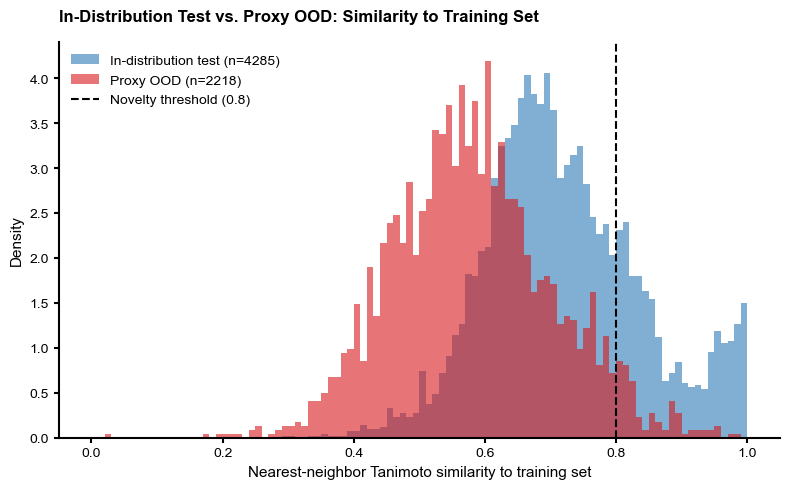

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(0, 1, 101)
ax.hist(id_test_similarity, bins=bins, density=True, color="#2c7bb6", alpha=0.6, label=f"In-distribution test (n={len(id_test_similarity)})")
ax.hist(proxy_ood_similarity, bins=bins, density=True, color="#d7191c", alpha=0.6, label=f"Proxy OOD (n={len(proxy_ood_similarity)})")
ax.axvline(
    NOVELTY_THRESHOLD, color="black", linestyle="--", linewidth=1.5,
    label=f"Novelty threshold ({NOVELTY_THRESHOLD})",
)
ax.legend(frameon=False)

ax.set_xlabel("Nearest-neighbor Tanimoto similarity to training set")
ax.set_ylabel("Density")
ax.set_title("In-Distribution Test vs. Proxy OOD: Similarity to Training Set", loc="left", fontweight="bold", pad=15)

plt.tight_layout()
plt.show()